<a href="https://colab.research.google.com/github/eduardokern/ML/blob/recommendation/notebook/recommendation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1>Sistema de recomendação por imagens</h1>

Depois de entender o funcionamento de Sistemas de Recomendação e suas aplicações, neste projeto vamos então desenvolver um modelo capaz de classificar imagens por sua similaridade e gerar resultados para o usuário de um site. Os resultados esperados são direcionados para, por meio de um produto buscado na internet, o Sistema de Recomendação deve indicar produtos relacionados, mas não por seus dados textuais (preço, modelo, marca, loja) e, sim, por sua aparência física (formato, cor, textura, etc).  

Para que este sistema seja desenvolvido, vamos treinar uma rede de Deep Learning com várias classes de objetos, como por exemplo: relógio, camiseta, bicicleta, sapato, etc.  Dentro de cada classe devemos ter objetos que são parecidos em sua aparência, como pode ser visto na figura a seguir:

![Figura 1: Objetos similares em sua aparência.](https://drive.google.com/uc?export=view&id=1An9bIws6u3hD1z50NrZc4ZAcOhnKf8-3)

Para exemplo, podemos então utilizar o sistema de recomendação por imagens apresentado a seguir:
https://colab.research.google.com/github/sparsh-ai/rec-tutorials/blob/master/_notebooks/2021-04-27-image-similarity-recommendations.ipynb



In [1]:
# Mount google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [13]:
%matplotlib inline

import os
import keras
import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import imshow
from keras.applications.imagenet_utils import preprocess_input
from keras.layers import Dense, Dropout, Flatten, Activation
from keras.layers import Conv2D, MaxPooling2D
from keras.models import Model
from keras.preprocessing import image


In [3]:
root = '/content/drive/MyDrive/Colab/ML/datasets'
categories_path = [x[0] for x in os.walk(root) if x[0]][1:]
print(categories_path)

['/content/drive/MyDrive/Colab/ML/datasets/tennis_racquet', '/content/drive/MyDrive/Colab/ML/datasets/hat', '/content/drive/MyDrive/Colab/ML/datasets/footwear', '/content/drive/MyDrive/Colab/ML/datasets/ball_pack']


In [4]:
# helper function to load image and return it and input vector
def get_image(path):
  try:
    img = image.load_img(path, target_size=(224, 224), keep_aspect_ratio=True)
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)
    return img, x
  except Exception as e:
    print(f'Error loading: {path}')
    return None, None

<h2>Loading datasets</h2>

In [5]:
datasets = {}
for c, cat_path in enumerate(categories_path):
  category = cat_path.split('/')[-1]
  datasets[category] = []
  print(f'Loading {category} from {cat_path}')
  images = [os.path.join(dp, f) for dp, dn, filenames
            in os.walk(cat_path) for f in filenames
            if os.path.splitext(f)[1].lower() in ['.jpg','.png','.jpeg', '.jfif']]
  for img_path in images:
    img, x = get_image(img_path)
    if img is not None:
      datasets[category].append({'x':np.array(x[0]), 'y':c, 'path': img_path})

# count the number of classes
num_classes = len(datasets)
for cat, images in datasets.items():
  print(f'{cat}: {len(images)}')

Loading tennis_racquet from /content/drive/MyDrive/Colab/ML/datasets/tennis_racquet
Loading hat from /content/drive/MyDrive/Colab/ML/datasets/hat
Loading footwear from /content/drive/MyDrive/Colab/ML/datasets/footwear
Loading ball_pack from /content/drive/MyDrive/Colab/ML/datasets/ball_pack
tennis_racquet: 504
hat: 177
footwear: 244
ball_pack: 55


<h2>Creating training, validating and testing datasets (70%, 20%, 10%)

In [6]:
train_split = 0.7
val_split = 0.15

train = []
val = []
test = []
for cat, images in datasets.items():
  random.shuffle(images)
  idx_val = int(train_split * len(images))
  idx_test = int((train_split + val_split) * len(images))
  train += images[:idx_val]
  val += images[idx_val:idx_test]
  test += images[idx_test:]

print(f'Train size: {len(train)}')
print(f'Val size: {len(val)}')
print(f'Test size: {len(test)}')

Train size: 683
Val size: 148
Test size: 149


<h2>Splitting image data and label into different arrays

In [7]:
x_train, y_train = np.array([t["x"] for t in train]), [t["y"] for t in train]
x_val, y_val = np.array([t["x"] for t in val]), [t["y"] for t in val]
x_test, y_test = np.array([t["x"] for t in test]), [t["y"] for t in test]

In [8]:
# normalize data
x_train = x_train.astype('float32') /255.
x_val = x_val.astype('float32') /255.
x_test = x_test.astype('float32') /255.

# convert labels to one-hot vectors
y_train = keras.utils.to_categorical(y_train, num_classes)
y_val = keras.utils.to_categorical(y_val, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

<h2>Training the new dataset with transfer learning</h2>
Using VGG16 from keras and weight from ImageNet

In [9]:
vgg = keras.applications.VGG16(weights='imagenet', include_top=True)
vgg.summary()

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 15s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ fc1 (Dense)                          │ (None, 4096)                │     102,764,544 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

<h2>Replacing classification layer</h2>

In [10]:
# make a reference to VGG's input layer
inp = vgg.input

# make a new softmax layer with num_classes neurons
new_classification_layer = Dense(num_classes, activation='softmax')

# connect our new layer to the second to last layer in VGG, and make a reference to it
out = new_classification_layer(vgg.layers[-2].output)

# create a new network between inp and out
model_new = Model(inp, out)

<h2>Training</h2>

In [11]:
# make all layers untrainable by freezing weights (except for last layer)
for l, layer in enumerate(model_new.layers[:-1]):
    layer.trainable = False

# ensure the last layer is trainable/not frozen
for l, layer in enumerate(model_new.layers[-1:]):
    layer.trainable = True

model_new.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

model_new.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ fc1 (Dense)                          │ (None, 4096)                │     102,764,544 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 134,276,932 (512.23 MB)

 Trainable params: 16,388 (64.02 KB)

 Non-trainable params: 134,260,544 (512.16 MB)

In [12]:
history = model_new.fit(
    x_train, y_train,
    batch_size=128,
    epochs=20,
    validation_data=(x_val, y_val))

Epoch 1/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 59s 5s/step - accuracy: 0.3866 - loss: 1.8619 - val_accuracy: 0.5608 - val_loss: 1.1318
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 737ms/step - accuracy: 0.5335 - loss: 1.1709 - val_accuracy: 0.5541 - val_loss: 0.8552
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 738ms/step - accuracy: 0.6323 - loss: 0.8221 - val_accuracy: 0.9122 - val_loss: 0.6056
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 646ms/step - accuracy: 0.9069 - loss: 0.5707 - val_accuracy: 0.8784 - val_loss: 0.4522
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 639ms/step - accuracy: 0.8594 - loss: 0.4464 - val_accuracy: 0.9324 - val_loss: 0.3679
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 647ms/step - accuracy: 0.9331 - loss: 0.3579 - val_accuracy: 0.9662 - val_loss: 0.3201
Epoch 7/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 759ms/step - accuracy: 0.9479 - loss: 0.3123 - val_accuracy: 0.9392 - val_loss: 0.2833
Epoch 8/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 654ms/step - accuracy: 0.9468 - loss: 0.2778 - val_accuracy: 0.9662 - val_loss: 0

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━

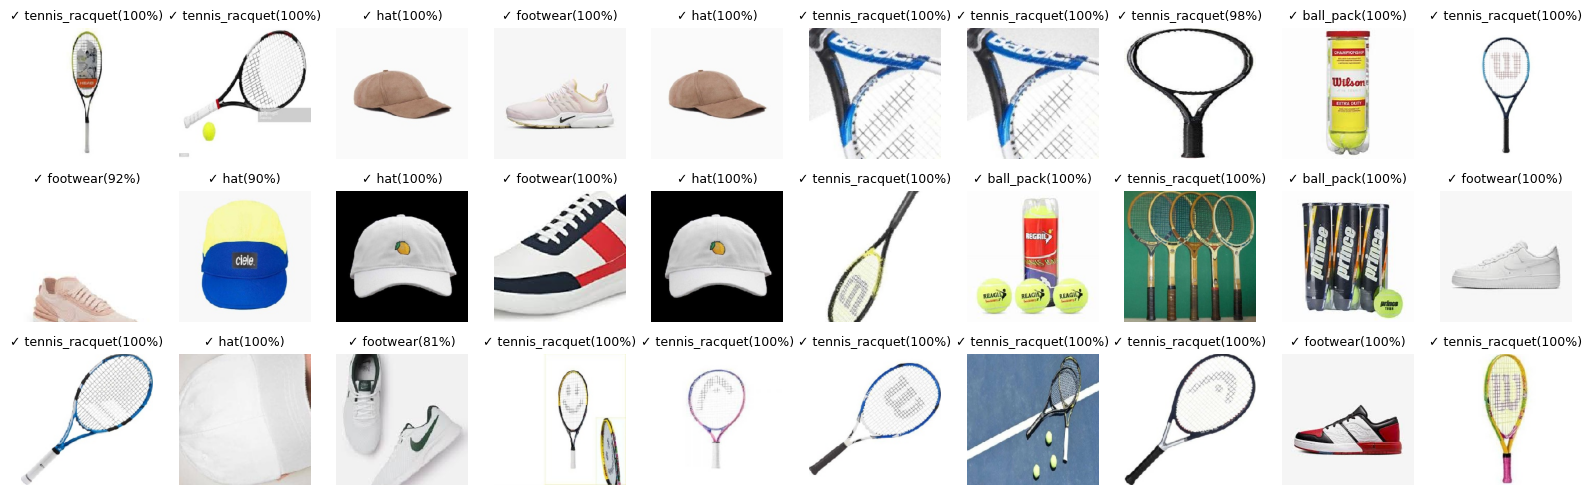

In [19]:
rows = 3
columns = 10
count = rows * columns
fig, axs = plt.subplots(rows, columns, figsize=(20, 6))
idxs = [int(len(test) * random.random()) for i in range(count)]
i = 0
categories = list(datasets.keys())
for row in range(rows):
  for col in range(columns):
    idx = idxs[i]
    img = image.load_img(test[idx]['path'], target_size=(224, 224), keep_aspect_ratio=True)
    data = test[idx]['x']
    category = test[idx]['y']
    probabilities = model_new.predict(np.array([data]))
    prob = probabilities[0][category]
    status = '✓' if prob > 0.5 else '✗'
    axs[row][col].imshow(img)
    axs[row][col].set_title(f'{status} {categories[category]}({prob*100:.0f}%)', fontsize=9)
    axs[row][col].axis('off')
    i += 1